#EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Let's also visualise the data as well

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

To visualise the numeric data 

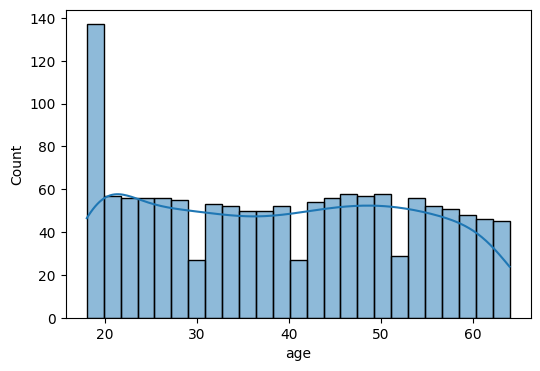

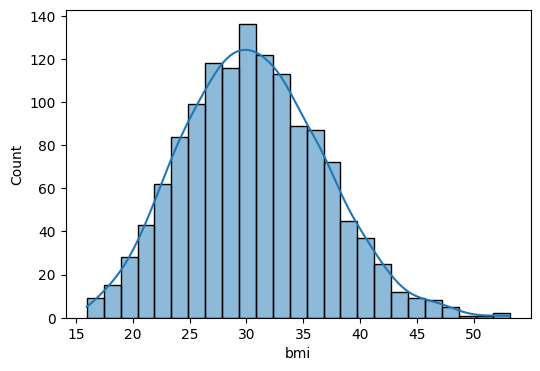

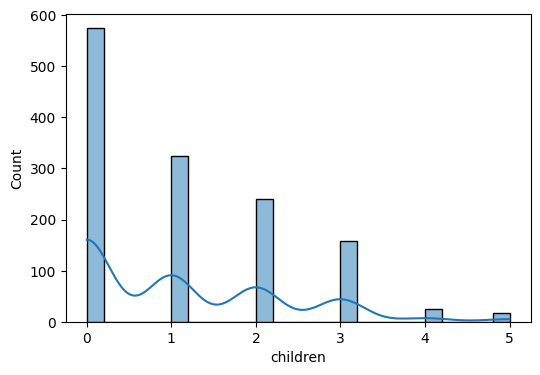

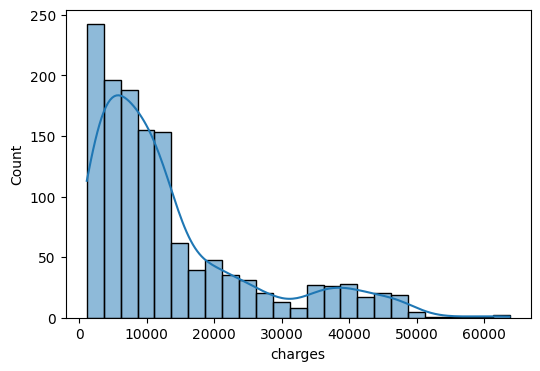

In [9]:
numeric_columns =['age','bmi', 'children', 'charges']
for i in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True,bins=25)

To visualise the categorical data

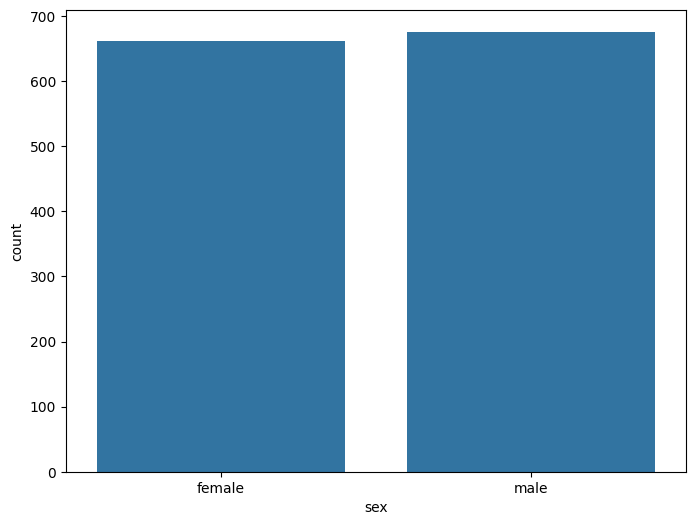

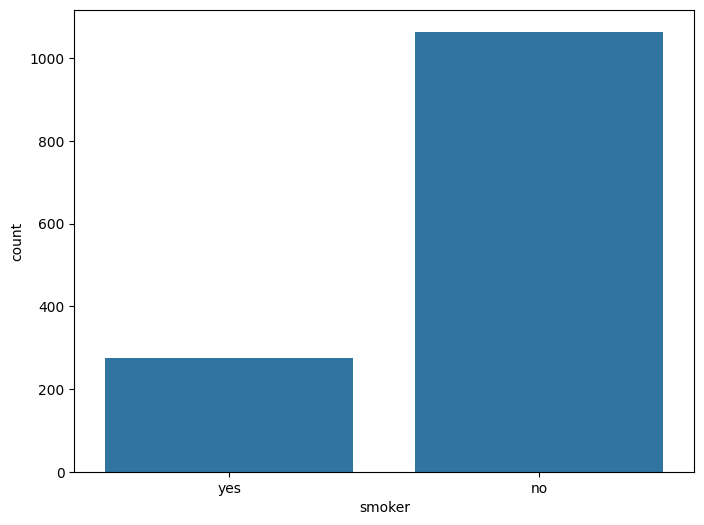

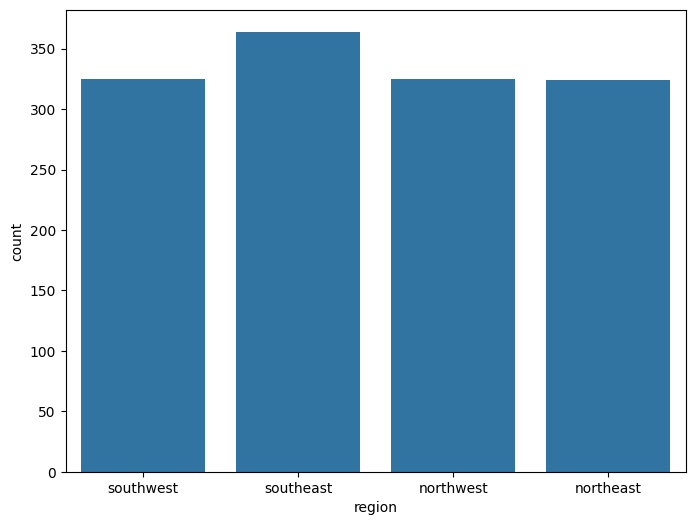

In [10]:
categorical_columns = ['sex', 'smoker', 'region']
for i in categorical_columns:
    plt.figure(figsize=(8,6))
    sns.countplot(x=df[i])

Let's create an histplot to find the outliers

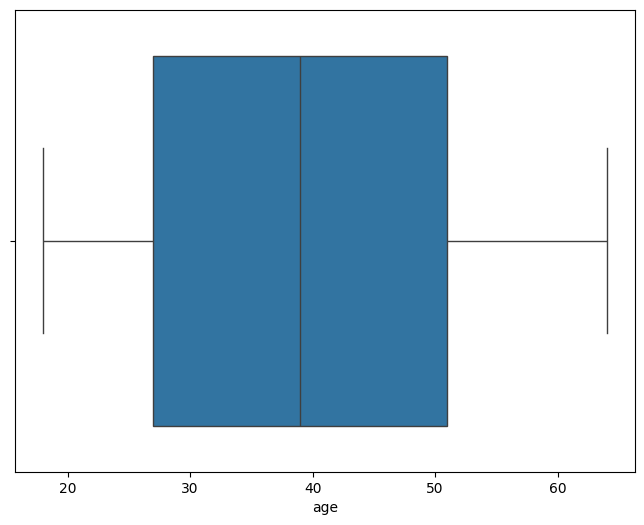

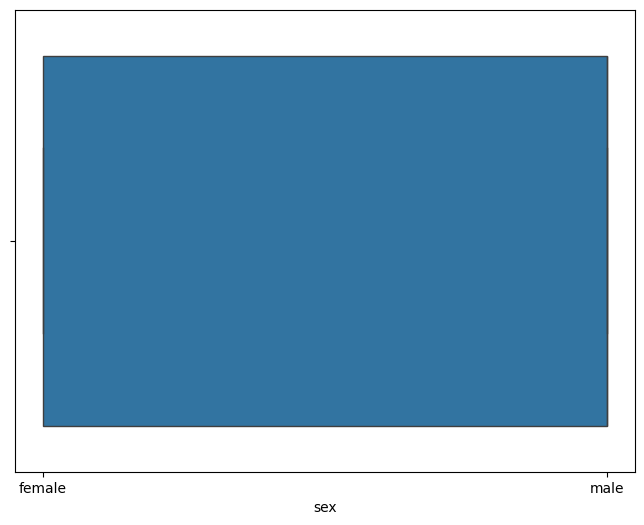

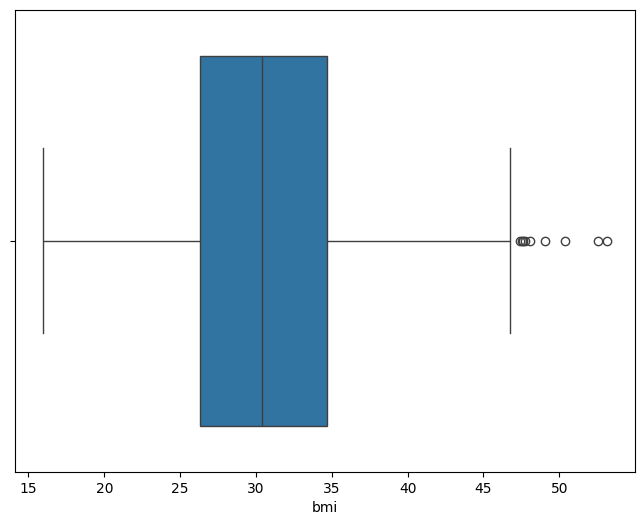

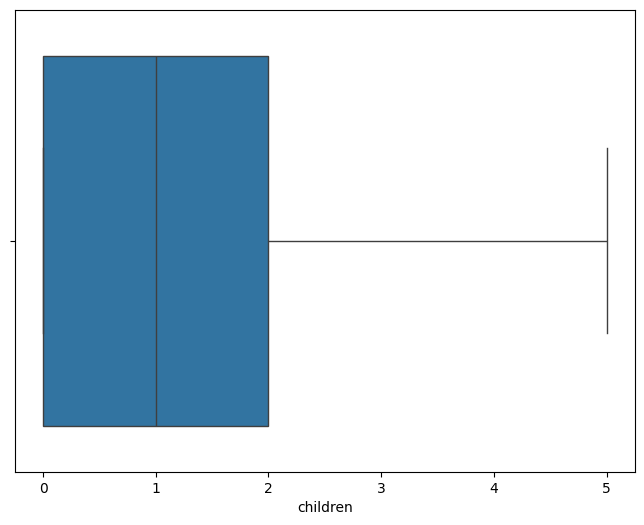

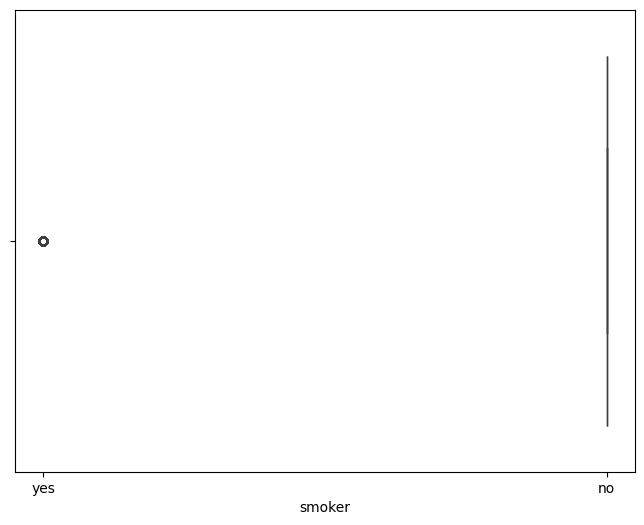

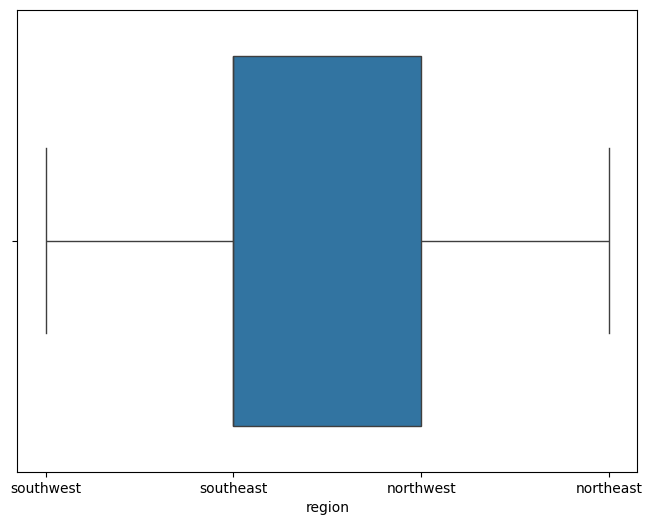

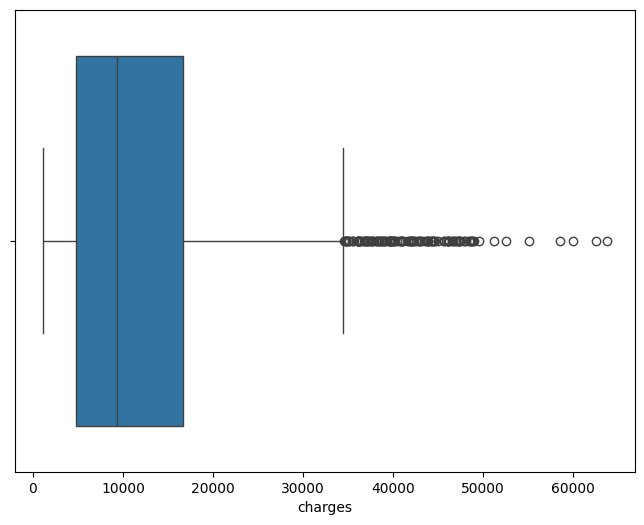

In [11]:
all_data = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
for i in all_data:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[i])

Let's find the correlation

<Axes: >

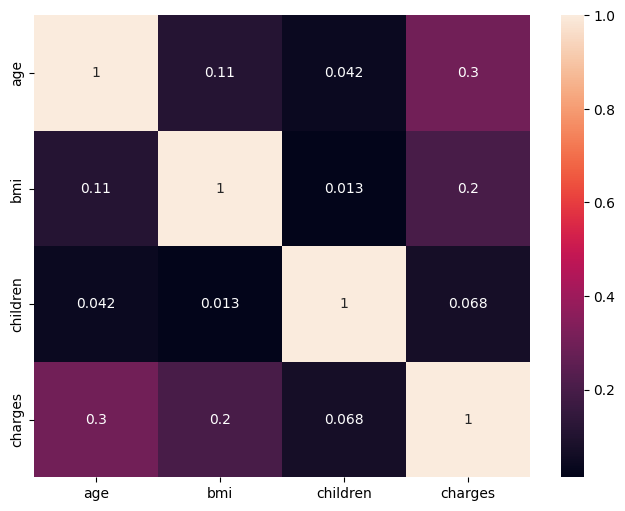

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot = True)

# Data Cleaning and Processing

In [13]:
df_cleaned = df.copy()
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
df_cleaned.shape

(1338, 7)

In [15]:
df_cleaned.drop_duplicates(inplace=True)

In [16]:
df_cleaned.shape

(1337, 7)

In [17]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


In [18]:
df_cleaned.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

# Data Labelling

Now since there is a string/object in sex,smoke and region, we have to replace it with numeric data

In [20]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [21]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male':1,'female':0})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [22]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [23]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes':1,'no':0})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [24]:
df_cleaned.rename(columns={
    'sex':'is_male'
},inplace=True)
df_cleaned.head()

,age,is_male,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [25]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

For regions, One Hot Encoding will be used, such that labelling multiple types of data(in a column) of a single column into multiple column

In [26]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'])
df_cleaned.head()

,age,is_male,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


Now to convert true and false to 1 and 0

In [27]:
df_cleaned = df_cleaned.astype(int)

# Feature Engineering

Creating new columns for ML model to learn from 

<Axes: xlabel='bmi', ylabel='Count'>

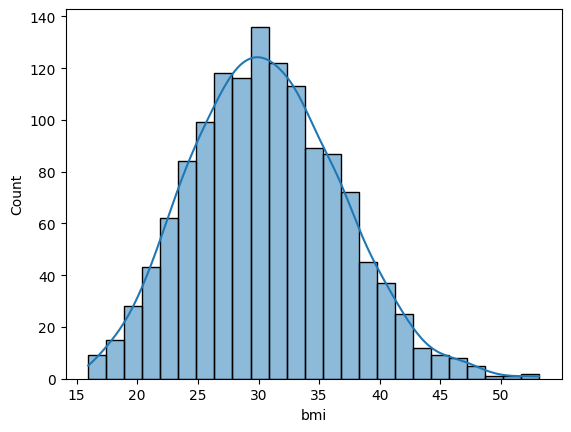

In [28]:
sns.histplot(df['bmi'],kde=True)

In [29]:
df_cleaned['bmi_cleaned']=pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9,53],#53 because that's the max bmi (try: df_cleaned['bmi'].max())
    labels=['Underweight','Normal','Overweight','Obese']
)

In [30]:
df_cleaned.head()

,age,is_male,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cleaned
0,19,0,27,0,1,16884,0,0,0,1,Overweight
1,18,1,33,1,0,1725,0,0,1,0,Obese
2,28,1,33,3,0,4449,0,0,1,0,Obese
3,33,1,22,0,0,21984,0,1,0,0,Normal
4,32,1,28,0,0,3866,0,1,0,0,Overweight


In [31]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_cleaned'])


In [32]:
df_cleaned.head()

,age,is_male,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cleaned_Underweight,bmi_cleaned_Normal,bmi_cleaned_Overweight,bmi_cleaned_Obese
0,19,0,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,1,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,1,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,1,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,1,28,0,0,3866,0,1,0,0,False,False,True,False


In [33]:
df_cleaned = df_cleaned.astype(int)

In [34]:
df_cleaned.head()

,age,is_male,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cleaned_Underweight,bmi_cleaned_Normal,bmi_cleaned_Overweight,bmi_cleaned_Obese
0,19,0,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,1,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,1,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,1,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,1,28,0,0,3866,0,1,0,0,0,0,1,0


# Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler    
cols = ['age','bmi','children']
df_cleaned[cols] = StandardScaler().fit_transform(df_cleaned[cols])

In [36]:
df_cleaned.head()

,age,is_male,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cleaned_Underweight,bmi_cleaned_Normal,bmi_cleaned_Overweight,bmi_cleaned_Obese
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,1,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,1,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,1,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


# Feature Selection

In [37]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [   
    'age', 'bmi', 'children', 'is_male', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_cleaned_Normal', 'bmi_cleaned_Overweight', 'bmi_cleaned_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,smoker,0.787234
0,age,0.298309
10,bmi_cleaned_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
3,is_male,0.058046
5,region_northwest,-0.038695
7,region_southwest,-0.043637
8,bmi_cleaned_Normal,-0.104042


So which of these columns should be usd in Machine Learning? Let's Find out by CHI - Test

In [38]:
cat_features = [
    'is_male', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_cleaned_Normal', 'bmi_cleaned_Overweight', 'bmi_cleaned_Obese'
]

In [39]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_male,10.258784,0.01649,Reject Null (Keep Feature)
bmi_cleaned_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_cleaned_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_cleaned_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


Therefor the ones which could be used to perform ML are given above (Reject Null(keep Feature) only)

In [40]:
final_df = df_cleaned[['age', 'is_male', 'bmi', 'children', 'smoker', 'charges','region_southeast','bmi_cleaned_Obese']]
final_df

,age,is_male,bmi,children,smoker,charges,region_southeast,bmi_cleaned_Obese
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,1,0.462463,-0.079442,0,1725,1,1
2,-0.799350,1,0.462463,1.580143,0,4449,1,1
3,-0.443201,1,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,1,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,0,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,0,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,0,-0.844753,-0.909234,0,2007,0,0
